 What GraphRAG Adds
• 	Entity Graphs: Instead of plain text chunks, you build a graph of entities and relationships.
• 	Contextual Retrieval: Queries traverse the graph to pull semantically related nodes.
• 	Structured Output: Graph paths can be handed off to GPT‑4o for synthesis into natural language.

In [1]:
!pip install langchain networkx openai

In [2]:
# Install dependencies
import networkx as nx
from openai import OpenAI
import matplotlib.pyplot as plt
client = OpenAI()

Build Graph from Documents

In [3]:
# Example: build a simple entity graph
G = nx.Graph()
G.add_edge("Car", "Pollution", relation="emits CO2")
G.add_edge("Bus", "Public Transport", relation="reduces congestion")
G.add_edge("Truck", "Logistics", relation="delivers goods")

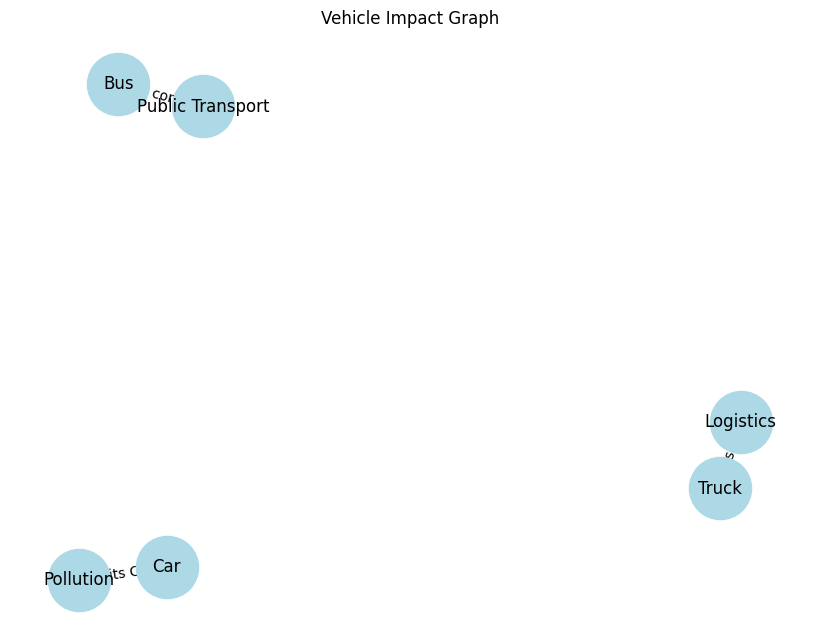

In [4]:
pos = nx.spring_layout(G)
edge_labels = nx.get_edge_attributes(G, 'relation')

plt.figure(figsize=(8,6))
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000, font_size=12, arrows=True)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='black')
plt.title("Vehicle Impact Graph")
plt.axis("off")
plt.show()

Graph-Based Retrieval

In [5]:
def graph_retrieve(query, graph):
    # naive retrieval: find neighbors of query term
    if query in graph:
        neighbors = list(graph.neighbors(query))
        context = [f"{query} -- {graph[query][n]['relation']} --> {n}" for n in neighbors]
        return "\n".join(context)
    return "No context found."
    
context = graph_retrieve("Car", G)
print(context)

Car -- emits CO2 --> Pollution


Branched RAG Merge

In [6]:
pdf_context = "PDF chunk: Vehicle emissions data..."
db_context = "DB entry: EV adoption statistics..."
graph_context = context

merged_context = f"""
PDF Context:
{pdf_context}

Database Context:
{db_context}

Graph Context:
{graph_context}
"""

GPT‑4o Synthesis

In [7]:
response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[
        {"role": "system", "content": "You are a Branched GraphRAG assistant. Use all contexts to answer clearly."},
        {"role": "user", "content": f"Query: What is the impact of cars?\n\n{merged_context}"}
    ]
)

print(response.choices[0].message.content)

The impact of cars primarily revolves around their emissions, which significantly contribute to pollution through the release of CO2 and other harmful pollutants. The PDF context highlights that vehicle emissions data indicates that conventional cars are major contributors to air pollution and greenhouse gas effects. Furthermore, the Graph Context outlines a direct relationship where cars emit CO2, leading to increased pollution levels.

Additionally, the Database Context points to the growing adoption of electric vehicles (EVs), which presents an alternative that may mitigate some of the negative impacts associated with traditional gasoline or diesel vehicles. The transition to EVs can potentially reduce overall emissions and improve air quality, thereby addressing some of the environmental concerns linked with car usage. 

In summary, while cars have a significant negative impact on pollution due to emissions, the shift towards electric vehicles may help alleviate some of this impact